In [1]:
!pip install timm
!pip install einops
!pip install gradio
!pip install torchmetrics

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt

from einops import rearrange
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
IMAGE_SIZE = 224
PATCH_SIZE = 16

NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2  # 196 patches

MASK_RATIO = 0.75
VISIBLE_PATCHES = int(NUM_PATCHES * (1 - MASK_RATIO))  # 49
MASKED_PATCHES = NUM_PATCHES - VISIBLE_PATCHES         # 147

BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 0.05

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [6]:
import os
os.listdir("/kaggle/input/datasets")

['akash2sharma']

In [7]:
os.listdir("/kaggle/input/datasets/akash2sharma")

['tiny-imagenet']

In [8]:
os.listdir("/kaggle/input/datasets/akash2sharma/tiny-imagenet")

['tiny-imagenet-200']

In [9]:
os.listdir("/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200")

['words.txt', 'wnids.txt', 'tiny-imagenet-200', 'val', 'test', 'train']

In [10]:
data_path = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train"

In [11]:
train_dataset = ImageFolder(
    root=data_path,
    transform=transform
)

In [12]:
print(len(train_dataset))

100000


In [13]:
def patchify(images, patch_size=16):
    
    B, C, H, W = images.shape
    
    assert H % patch_size == 0 and W % patch_size == 0
    
    patches = images.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    
    patches = patches.contiguous().view(B, C, -1, patch_size, patch_size)
    
    patches = patches.permute(0,2,1,3,4)
    
    patches = patches.reshape(B, -1, C * patch_size * patch_size)
    
    return patches

In [14]:
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

data_path = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train"

train_dataset = ImageFolder(
    root=data_path,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

In [15]:
print(len(train_loader))

3125


In [16]:
images, _ = next(iter(train_loader))

patches = patchify(images)

print("Patch shape:", patches.shape)

Patch shape: torch.Size([32, 196, 768])


(np.float64(-0.5), np.float64(15.5), np.float64(15.5), np.float64(-0.5))

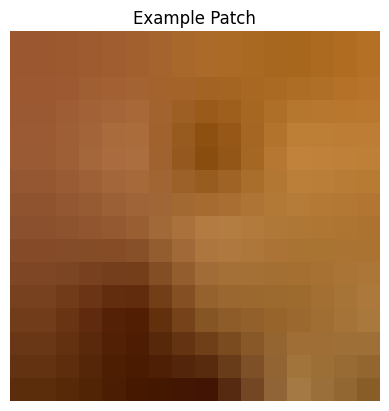

In [17]:
sample_patch = patches[0,0]

patch_img = sample_patch.reshape(3,16,16).permute(1,2,0)

plt.imshow(patch_img)
plt.title("Example Patch")
plt.axis("off")

In [18]:
def random_masking(x, mask_ratio=0.75):

    B, N, D = x.shape   # batch, patches, dim

    len_keep = int(N * (1 - mask_ratio))   # 49 patches

    noise = torch.rand(B, N, device=x.device)

    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)

    ids_keep = ids_shuffle[:, :len_keep]

    x_visible = torch.gather(
        x,
        dim=1,
        index=ids_keep.unsqueeze(-1).repeat(1,1,D)
    )

    mask = torch.ones([B, N], device=x.device)
    mask[:, :len_keep] = 0

    mask = torch.gather(mask, dim=1, index=ids_restore)

    return x_visible, mask, ids_restore

In [19]:
patches = patchify(images)

visible_patches, mask, ids_restore = random_masking(patches)

print("Visible patches shape:", visible_patches.shape)
print("Mask shape:", mask.shape)

Visible patches shape: torch.Size([32, 49, 768])
Mask shape: torch.Size([32, 196])


In [20]:
print("Masked patches:", mask.sum().item())

Masked patches: 4704.0


In [21]:
class PatchEmbedding(nn.Module):
    
    def __init__(self, patch_dim=768, embed_dim=768):
        super().__init__()
        
        self.proj = nn.Linear(patch_dim, embed_dim)

    def forward(self, x):
        x = self.proj(x)
        return x

In [22]:
class PositionalEmbedding(nn.Module):

    def __init__(self, num_patches=196, embed_dim=768):
        super().__init__()

        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches, embed_dim)
        )

    def forward(self, x):
        return x + self.pos_embed[:, :x.size(1), :]

In [23]:
class TransformerBlock(nn.Module):

    def __init__(self, dim=768, heads=12, mlp_ratio=4.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim*mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim*mlp_ratio), dim)
        )

    def forward(self, x):

        x = x + self.attn(
            self.norm1(x),
            self.norm1(x),
            self.norm1(x)
        )[0]

        x = x + self.mlp(self.norm2(x))

        return x

In [24]:
class ViTEncoder(nn.Module):

    def __init__(self,
                 num_patches=196,
                 embed_dim=768,
                 depth=12,
                 heads=12):

        super().__init__()

        self.patch_embed = PatchEmbedding()

        self.pos_embed = PositionalEmbedding(
            num_patches=num_patches,
            embed_dim=embed_dim
        )

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, heads)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):

        x = self.patch_embed(x)

        x = self.pos_embed(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        return x

In [25]:
encoder = ViTEncoder().to(device)

visible_patches = visible_patches.to(device)

latent = encoder(visible_patches)

print("Encoder output shape:", latent.shape)

Encoder output shape: torch.Size([32, 49, 768])


In [26]:
class EncoderToDecoder(nn.Module):
    
    def __init__(self, encoder_dim=768, decoder_dim=384):
        super().__init__()
        
        self.proj = nn.Linear(encoder_dim, decoder_dim)

    def forward(self, x):
        return self.proj(x)

In [27]:
class MaskToken(nn.Module):
    
    def __init__(self, decoder_dim=384):
        super().__init__()
        
        self.mask_token = nn.Parameter(
            torch.zeros(1, 1, decoder_dim)
        )

    def forward(self, batch_size, num_tokens):
        
        return self.mask_token.repeat(batch_size, num_tokens, 1)

In [28]:
class DecoderBlock(nn.Module):

    def __init__(self, dim=384, heads=6, mlp_ratio=4.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim*mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim*mlp_ratio), dim)
        )

    def forward(self, x):

        x = x + self.attn(
            self.norm1(x),
            self.norm1(x),
            self.norm1(x)
        )[0]

        x = x + self.mlp(self.norm2(x))

        return x

In [29]:
class ViTDecoder(nn.Module):

    def __init__(self,
                 num_patches=196,
                 decoder_dim=384,
                 depth=12,
                 heads=6,
                 patch_dim=768):

        super().__init__()

        self.mask_token = nn.Parameter(
            torch.zeros(1, 1, decoder_dim)
        )

        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches, decoder_dim)
        )

        self.blocks = nn.ModuleList([
            DecoderBlock(decoder_dim, heads)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(decoder_dim)

        self.head = nn.Linear(decoder_dim, patch_dim)

    def forward(self, x, ids_restore):

        B, N, D = x.shape

        mask_tokens = self.mask_token.repeat(
            B,
            ids_restore.shape[1] - N,
            1
        )

        x_ = torch.cat([x, mask_tokens], dim=1)

        x_ = torch.gather(
            x_,
            dim=1,
            index=ids_restore.unsqueeze(-1).repeat(1,1,D)
        )

        x_ = x_ + self.pos_embed

        for block in self.blocks:
            x_ = block(x_)

        x_ = self.norm(x_)

        x_ = self.head(x_)

        return x_

In [30]:
proj = EncoderToDecoder().to(device)
decoder = ViTDecoder().to(device)

latent = proj(latent)

reconstructed = decoder(latent, ids_restore.to(device))

print("Decoder output:", reconstructed.shape)

Decoder output: torch.Size([32, 196, 768])


In [31]:
class MAE(nn.Module):
    def __init__(self,
                 image_size=224,
                 patch_size=16,
                 encoder_dim=768,
                 decoder_dim=384,
                 encoder_depth=12,
                 encoder_heads=12,
                 decoder_depth=12,
                 decoder_heads=6,
                 mask_ratio=0.75):
        super().__init__()

        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = 3 * patch_size * patch_size

        # Encoder & Decoder
        self.encoder = ViTEncoder(
            num_patches=int(self.num_patches*(1-mask_ratio)),
            embed_dim=encoder_dim,
            depth=encoder_depth,
            heads=encoder_heads
        )
        self.encoder_to_decoder = EncoderToDecoder(
            encoder_dim=encoder_dim,
            decoder_dim=decoder_dim
        )
        self.decoder = ViTDecoder(
            num_patches=self.num_patches,
            decoder_dim=decoder_dim,
            depth=decoder_depth,
            heads=decoder_heads,
            patch_dim=self.patch_dim
        )

    def patchify(self, images):
        B, C, H, W = images.shape
        patches = images.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.contiguous().view(B, C, -1, self.patch_size, self.patch_size)
        patches = patches.permute(0,2,1,3,4)
        patches = patches.reshape(B, -1, self.patch_dim)
        return patches

    def random_masking(self, x):
        B, N, D = x.shape
        len_keep = int(N * (1 - self.mask_ratio))
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_visible = torch.gather(
            x,
            dim=1,
            index=ids_keep.unsqueeze(-1).repeat(1,1,D)
        )
        return x_visible, ids_restore

    def forward(self, images):
        # Step 1: patchify
        patches = self.patchify(images)

        # Step 2: masking
        x_visible, ids_restore = self.random_masking(patches)

        # Step 3: encoder
        latent = self.encoder(x_visible)

        # Step 4: project to decoder dim
        latent = self.encoder_to_decoder(latent)

        # Step 5: decoder
        reconstructed = self.decoder(latent, ids_restore)

        return reconstructed, patches

In [32]:
images, _ = next(iter(train_loader))
images = images.to(device)

model = MAE().to(device)

reconstructed, original_patches = model(images)

print("Reconstructed patches shape:", reconstructed.shape)
print("Original patches shape:", original_patches.shape)

Reconstructed patches shape: torch.Size([32, 196, 768])
Original patches shape: torch.Size([32, 196, 768])


In [33]:
def mae_loss(reconstructed, original, mask, patch_size=16):
    # mask = 1 for masked patches, 0 for visible
    mask = mask.unsqueeze(-1).repeat(1,1,3*patch_size*patch_size)
    
    loss = ((reconstructed - original) ** 2 * mask).sum() / mask.sum()
    return loss

In [34]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [35]:
scaler = torch.amp.GradScaler(device="cuda")

In [36]:
# 8.1 Mixed Precision Scaler (new API)
scaler = torch.amp.GradScaler(device="cuda")

# 8.2 Optimizer and Scheduler
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# 8.3 Training Loop
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device)
        optimizer.zero_grad()

        # Mixed precision forward
        with torch.amp.autocast(device_type="cuda"):
            reconstructed, original = model(images)

            # Recreate mask for this batch
            _, mask = model.random_masking(model.patchify(images))
            mask = mask.to(device)

            # Compute MSE loss only on masked patches
            loss = mae_loss(reconstructed, original, mask)

        # Backprop with GradScaler
        scaler.scale(loss).backward()

        # Optional gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}, Avg Loss: {avg_loss:.4f}")

Epoch 1/10: 100%|██████████| 3125/3125 [15:19<00:00,  3.40it/s]


Epoch 1/10, Avg Loss: 0.0442


Epoch 2/10: 100%|██████████| 3125/3125 [15:14<00:00,  3.42it/s]


Epoch 2/10, Avg Loss: 0.0370


Epoch 3/10: 100%|██████████| 3125/3125 [15:16<00:00,  3.41it/s]


...

Epoch 8/10, Avg Loss: 0.0353


Epoch 9/10: 100%|██████████| 3125/3125 [15:16<00:00,  3.41it/s]


Epoch 9/10, Avg Loss: 0.0353


Epoch 10/10: 100%|██████████| 3125/3125 [15:16<00:00,  3.41it/s]

Epoch 10/10, Avg Loss: 0.0353


In [37]:
def unpatchify(patches, patch_size=16, img_size=224):
    B, N, D = patches.shape
    C = D // (patch_size * patch_size)
    H = W = int(img_size / patch_size)

    patches = patches.reshape(B, H*W, C, patch_size, patch_size)
    patches = patches.permute(0,2,1,3,4)  # B, C, N, p, p
    patches = patches.reshape(B, C, H, W, patch_size, patch_size)
    patches = patches.permute(0,1,2,4,3,5)
    patches = patches.reshape(B, C, img_size, img_size)
    return patches

In [40]:
def visualize_reconstruction(model, dataloader, num_samples=5):

    model.eval()

    images, _ = next(iter(dataloader))
    images = images[:num_samples].to(device)

    with torch.no_grad():
        reconstructed, _ = model(images)

    recon_images = unpatchify(reconstructed)

    plt.figure(figsize=(12, num_samples*3))

    for i in range(num_samples):

        # Original image
        plt.subplot(num_samples, 2, i*2+1)
        img = images[i].cpu().permute(1,2,0)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        # Reconstructed image
        plt.subplot(num_samples, 2, i*2+2)
        img = recon_images[i].cpu().permute(1,2,0).clamp(0,1)
        plt.imshow(img)
        plt.title("Reconstruction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

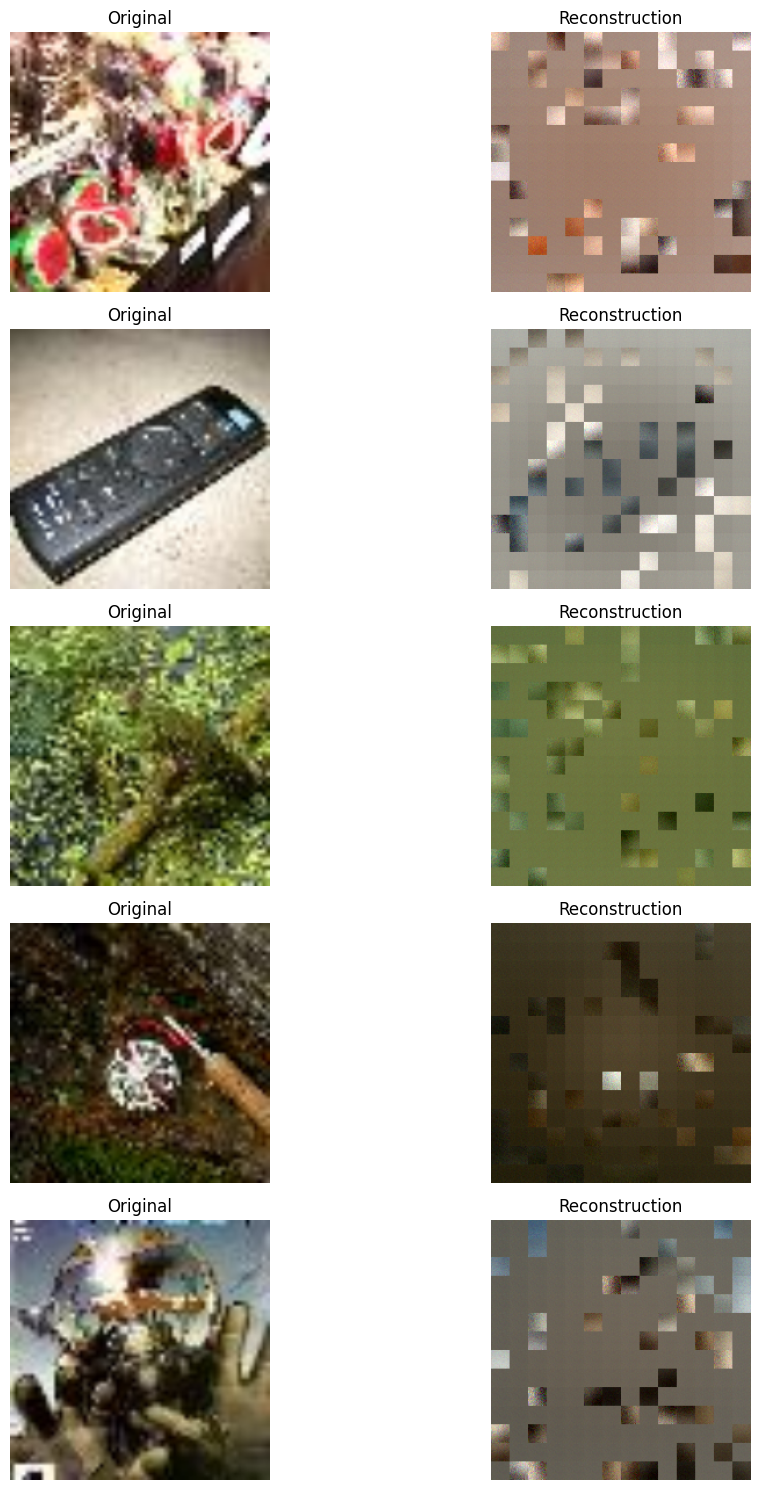

In [41]:
visualize_reconstruction(model, train_loader, num_samples=5)

In [43]:
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

In [45]:
def evaluate_model(model, dataloader, num_samples=5):

    model.eval()

    images, _ = next(iter(dataloader))
    images = images[:num_samples].to(device)

    with torch.no_grad():
        reconstructed, _ = model(images)

    recon_images = unpatchify(reconstructed)

    psnr_scores = []
    ssim_scores = []

    for i in range(num_samples):

        original = images[i].unsqueeze(0)
        recon = recon_images[i].unsqueeze(0)

        psnr = psnr_metric(recon, original)
        ssim = ssim_metric(recon, original)

        psnr_scores.append(psnr.item())
        ssim_scores.append(ssim.item())

    print("PSNR Scores:", psnr_scores)
    print("SSIM Scores:", ssim_scores)

    print("\nAverage PSNR:", sum(psnr_scores)/len(psnr_scores))
    print("Average SSIM:", sum(ssim_scores)/len(ssim_scores))

In [46]:
evaluate_model(model, train_loader, num_samples=5)

PSNR Scores: [13.851911544799805, 14.54637336730957, 16.556018829345703, 15.069456100463867, 13.909269332885742]
SSIM Scores: [0.39452600479125977, 0.27506524324417114, 0.5139952898025513, 0.2361508309841156, 0.3896709680557251]

Average PSNR: 14.786605834960938
Average SSIM: 0.3618816673755646


In [47]:
!pip install gradio

In [48]:
import gradio as gr
from PIL import Image
import numpy as np

In [49]:
def preprocess_image(image):

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    image = transform(image).unsqueeze(0).to(device)

    return image

In [51]:
def reconstruct_image(image, mask_ratio):

    model.eval()

    image = preprocess_image(image)

    with torch.no_grad():
        reconstructed, _ = model(image)

    recon_image = unpatchify(reconstructed)

    recon_image = recon_image.squeeze().cpu().permute(1,2,0).numpy()

    recon_image = np.clip(recon_image, 0, 1)

    return recon_image

In [52]:
interface = gr.Interface(
    fn=reconstruct_image,
    inputs=[
        gr.Image(type="pil"),
        gr.Slider(0.5, 0.9, value=0.75, label="Mask Ratio")
    ],
    outputs=gr.Image(),
    title="Masked Autoencoder Image Reconstruction",
    description="Upload an image and see how the MAE reconstructs masked regions."
)

In [53]:
interface.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://2aa9e6c8776d5f5d66.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
